# Solution Exercises Week 2

Lösungen zu den Aufgaben zur Datenmanipulation mit pandas.

Task 1 - Big Mac Prices
         date currency_code       name  local_price  dollar_ex  dollar_price
0  2000-04-01           ARS  Argentina         2.50          1          2.50
1  2000-04-01           AUD  Australia         2.59          1          2.59
2  2000-04-01           BRL     Brazil         2.95          1          2.95
3  2000-04-01           GBP    Britain         1.90          1          1.90
4  2000-04-01           CAD     Canada         2.85          1          2.85
Shape: (1946, 6)

Task 2 - Eggs per breed
{'New Hampshire Red': 297, 'Australorp': 213, 'Plymouth Rock': 314, 'Barnevelder': 316, 'ISA Brown': 225}

Task 3 - Car prices
Minimum: 160.00
Maximum: 428000.00
Mean: 27678.18


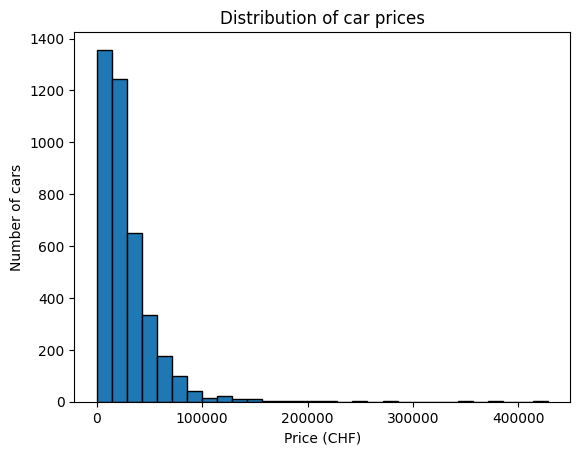


Task 4 - Personalised subset
Birthday month: 1
Fuel type: Diesel
Mean price: 25015.86


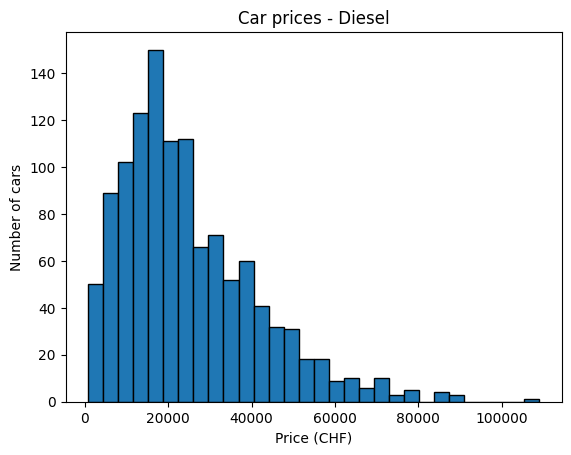

In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

DATA_DIR = Path.cwd()

# Task 1: BigmacPrice.csv
bigmac_df = pd.read_csv(DATA_DIR / "BigmacPrice.csv")
print("Task 1 - Big Mac Prices")
print(bigmac_df.head())
print(f"Shape: {bigmac_df.shape}")

# Task 2: ChickenData.xlsx
chicken_df = pd.read_excel(DATA_DIR / "ChickenData.xlsx")
eggs_by_breed = chicken_df.set_index("breed")["eggs_per_year"].to_dict()
print("\nTask 2 - Eggs per breed")
print(eggs_by_breed)

# Task 3: Cars_autoscout24.csv
cars_df = pd.read_csv(
    DATA_DIR / "Cars_autoscout24.csv",
    sep=";",
    encoding="latin1",
)

# Remove currency text, apostrophes and other non-numeric characters.
cars_df["Prices_numeric"] = pd.to_numeric(
    cars_df["Price"].astype(str).str.replace(r"[^0-9.-]", "", regex=True),
    errors="coerce",
)

print("\nTask 3 - Car prices")
print(f"Minimum: {cars_df['Prices_numeric'].min():.2f}")
print(f"Maximum: {cars_df['Prices_numeric'].max():.2f}")
print(f"Mean: {cars_df['Prices_numeric'].mean():.2f}")

cars_df["Prices_numeric"].dropna().plot.hist(bins=30, edgecolor="black")
plt.title("Distribution of car prices")
plt.xlabel("Price (CHF)")
plt.ylabel("Number of cars")
plt.show()

# Task 4: Change this to your birthday month (1-12).
birthday_month = 1

if not 1 <= birthday_month <= 12:
    raise ValueError("birthday_month muss zwischen 1 und 12 liegen.")

fuel_type = "Benzin" if birthday_month % 2 == 0 else "Diesel"
subset_df = cars_df.loc[cars_df["Fuel_Type"] == fuel_type].copy()
subset_df["Prices_numeric"] = pd.to_numeric(
    subset_df["Price"].astype(str).str.replace(r"[^0-9.-]", "", regex=True),
    errors="coerce",
)

subset_mean = subset_df["Prices_numeric"].mean()
print("\nTask 4 - Personalised subset")
print(f"Birthday month: {birthday_month}")
print(f"Fuel type: {fuel_type}")
print(f"Mean price: {subset_mean:.2f}")

subset_df["Prices_numeric"].dropna().plot.hist(bins=30, edgecolor="black")
plt.title(f"Car prices - {fuel_type}")
plt.xlabel("Price (CHF)")
plt.ylabel("Number of cars")
plt.show()